# Computer vision libaries in PyTorch
* [`torchvision`] https://docs.pytorch.org/vision/stable/index.html - base domain libariy for PyTorch computer vision
* `torchvision.datasets` - get datasets and data loading functions for computer vision
* `torchvision.models` - get pretrained computer vision models
* `torchvision.transforms` - functions for manipulating the vision data (image) to be suitable for use with an ML model
* `torch.utils.data.Dataset` - Base dataset class for PyTorch
* `torch.utils.data.DataLoader` - Create a Python iterable over a dataset

In [1]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

from pathlib import Path
import requests

In [2]:
# Download helper functions from Learn PyTorch repo
if Path("helper_functions.py").is_file():
  print("helper_functions.py is already exists, skipping downloading")
else:
  print("Download helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
    f.write(request.content)



helper_functions.py is already exists, skipping downloading


In [3]:
from helper_functions import accuracy_fn

# 1. Get a Dataset

In [4]:
# Setup training data
train_datasets_fMNIST = datasets.FashionMNIST(
    root="data",
    train=True, # Do we want the training dataset?
    download=True, # Do we want to download it?
    transform=torchvision.transforms.ToTensor(), # How do we want to transform the data
    target_transform=None # How do we want to transform the label data
)

test_datasets_fMNIST = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=torchvision.transforms.ToTensor(),
    target_transform=None
)

In [5]:
# Check some attributes of the dataset
len(train_datasets_fMNIST),len(test_datasets_fMNIST)

(60000, 10000)

In [6]:
class_name = train_datasets_fMNIST.classes
class_name

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [7]:
class_to_idx = train_datasets_fMNIST.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [8]:
train_datasets_fMNIST.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

Text(0.5, 1.0, 'Ankle boot')

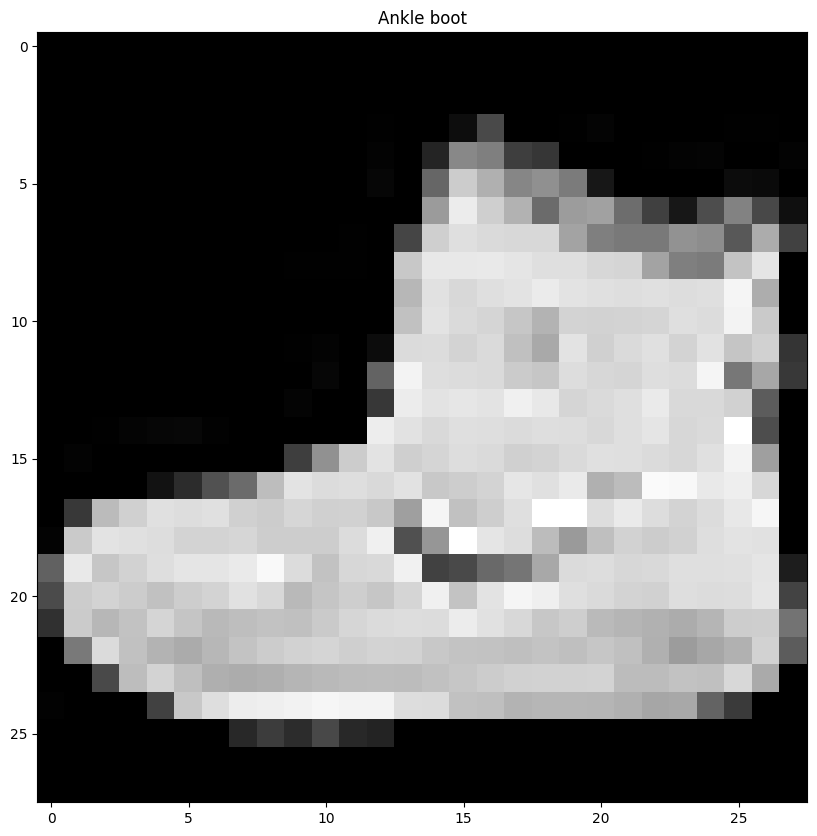

In [9]:
# Check out the first training sample
image, label = train_datasets_fMNIST[0]
plt.figure(figsize=[15,10])
plt.imshow(torch.permute(image,(1,2,0)),cmap='gray')
plt.title(class_name[label])

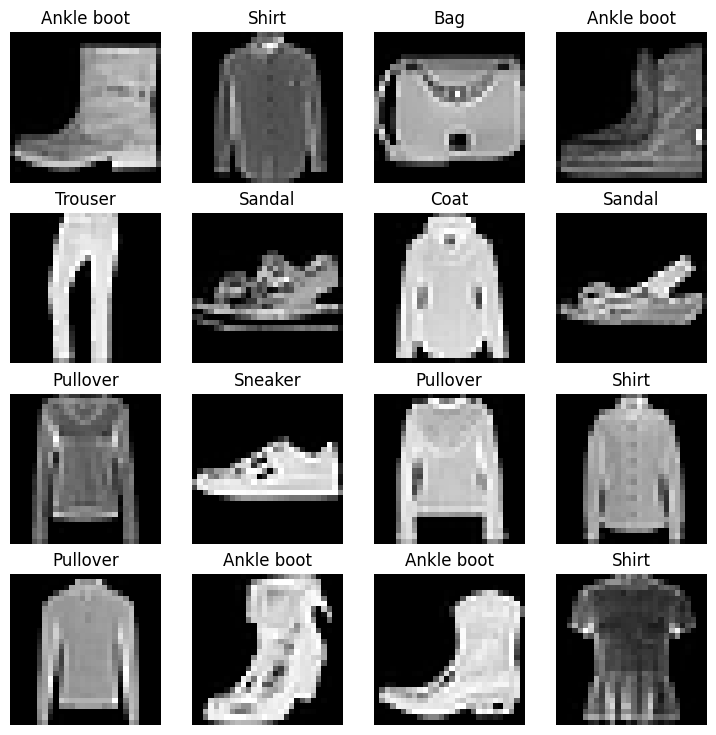

In [10]:
# Plot more image
torch.manual_seed(42)
fig = plt.figure(figsize=[9,9])
rows,cols = 4,4
for i in range(1,rows*cols+1):
  random_idx = torch.randint(0,len(train_datasets_fMNIST),size=[1]).item()
  image,label = train_datasets_fMNIST[random_idx]
  fig.add_subplot(rows,cols,i)
  plt.imshow(image.squeeze(),cmap='gray')
  plt.title(class_name[label])
  plt.axis(False)

# 2. Prepare DataLoader <=> Turn our data into mini-batches

Right now, the data is in the form of PyTorch Datasets.

DataLoader turns our data into a Python iterable.

More specifically, we want to turn our data into batches (or mini-batches). Because:
1. It is more computationally efficient, because the computer may not be able to look at (store in memory) 60000 images in one hit. So we break it down to 32 images at a time <=> batch size of 32
2. It gives our model more chances to update its gradient per epoch.


In [11]:
# Turn train datset into DataLoader
BATCH_SIZE = 32

train_dataloader = DataLoader(dataset=train_datasets_fMNIST,
                              batch_size=BATCH_SIZE,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_datasets_fMNIST,
                             batch_size=BATCH_SIZE,
                             shuffle=False)



In [12]:
# Chechout the dataloader
print(f"DataLoader: {train_dataloader,test_dataloader}")
print(f"Length of the train dataloader: {len(train_dataloader)} batches of 32")
print(f"Length of the test dataloader: {len(test_dataloader)} batches of 32")


DataLoader: (<torch.utils.data.dataloader.DataLoader object at 0x78ee5d026360>, <torch.utils.data.dataloader.DataLoader object at 0x78ee5d2555b0>)
Length of the train dataloader: 1875 batches of 32
Length of the test dataloader: 313 batches of 32


In [13]:
# Check out what's inside the training loader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape,train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

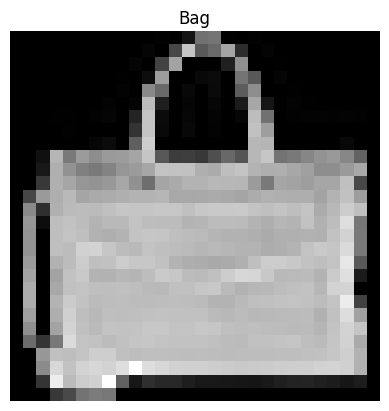

In [14]:
# Show a sample
# torch.manual_seed(42)
random_idx = torch.randint(0,len(train_features_batch),size=[1]).item()
img,label = train_features_batch[random_idx], train_labels_batch[random_idx]

plt.imshow(img.squeeze(),cmap='gray')
plt.title(class_name[label])
plt.axis(False)

In [15]:
label

tensor(8)

# 3. Model 0: Build a baseline model
Wehn starting to build a series of ML modelling experiments, it's best practice to start with a baseline model

A baseline model is a simple model you will try and improve upon with subsequent models/experiments



In [16]:
# Create a flatten layer
flatten_model = nn.Flatten()

# Get a single sample
x = train_features_batch[0]

# Flatten the sample
output = flatten_model(x)

print(f"Shape before flattening: {x.shape}") # -> [channels,H,W]
print(f"Shape after flattening: {output.shape}") # -> [channels, H*W]

Shape before flattening: torch.Size([1, 28, 28])
Shape after flattening: torch.Size([1, 784])


In [17]:
from torch.nn.modules.linear import Linear
# Create model_0
class FashionMNIST_ModelV0(nn.Module):
  def __init__(self, input_shape:int,
               hidden_units:int,
               output_shape:int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,out_features=hidden_units),
        nn.Linear(in_features=hidden_units,out_features=output_shape)
    )

  def forward(self,x):
    return self.layer_stack(x)


In [18]:
torch.manual_seed(42)

# Setup model with input parameters
model_0 = FashionMNIST_ModelV0(input_shape=28*28,
                               hidden_units=10,
                               output_shape=len(class_name)).to("cuda")

model_0

FashionMNIST_ModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [19]:
# dummy_x = torch.rand([1,1,28,28])
# model_0(dummy_x).squeeze()

In [20]:
# model_0(dummy_x).shape

# 4. Train Model

In [21]:
# Setup loss function
loss_fn = nn.CrossEntropyLoss()

# Setup optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)



## 4.2 Creating a function to time the experiments

Two of the main things often get tracked are:
* Model's performence (loss and accuracy,et)
* Run time

In [22]:
from timeit import default_timer as timer
def print_train_time(start:float,
                     end:float,
                     device:torch.device=None):
  """
  Prints difference between start and end time
  """
  total_time = end-start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time

In [23]:
start_time = timer()
# some code...
end_time = timer()

print_train_time(start_time,end_time,"gpu")

Train time on gpu: 0.000 seconds


4.030800027976511e-05

## 4.3 Create a training loop and train a model on batches data
1. Loop through epochs
2. Loop through traing batches, perform training step, calculate the train loss *per patch*
3. Loop through testing batches, perform testing steps, calculate the test loss *per patch*
4. Print
5. Time it all

In [24]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [25]:
# Import tqdm for progress bar
from tqdm.auto import tqdm
# Set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# Initialize
epochs = 3

# Training and test loop
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\m-----")
  ### Training
  train_loss = 0
  # Add a loop to loop through the training batches
  for batch,(X,y) in enumerate(train_dataloader):
    X,y = X.to(device),y.to(device)
    model_0.train()
    # Forward
    y_train_logits = model_0(X)
    # Loss
    loss = loss_fn(y_train_logits,y)
    train_loss += loss # accumulate the train loss
    # zero grad
    optimizer.zero_grad()
    # Backprob
    loss.backward()
    # Grad. descent
    optimizer.step()

    if batch % 400 ==0:
      print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples.")

  # Calculate the average training loss of the batches
  train_loss /= len(train_dataloader)

  ### Testing
  test_loss,acc_test = 0,0
  model_0.eval()
  with torch.inference_mode():
    for X_test,y_test in test_dataloader:
      X_test,y_test = X_test.to(device),y_test.to(device)
      # Forward
      y_test_logits = model_0(X_test)
      y_test_preds = torch.argmax(torch.softmax(y_test_logits,dim=1),dim=1)
      # Calculate the loss and acc
      loss = loss_fn(y_test_logits,y_test)
      acc = accuracy_fn(y_test,y_test_preds)
      test_loss += loss
      acc_test += acc

  # Calculate the average test_loss and test_acc per batch
    test_loss /= len(test_dataloader)
    acc_test /= len(test_dataloader)

  print(f"\nTrain loss: {train_loss:.4f} | Test loss: {test_loss:.4f} | Test acc: {acc_test:.4f}")

# Calculate the train time
train_time_end_on_cpu = timer()
total_train_time_on_cpu = print_train_time(start=train_time_start_on_cpu,
                                           end=train_time_end_on_cpu,
                                           device=str(next(model_0.parameters()).device))


<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_17719/2135502793.py:12: SyntaxWarning: invalid escape sequence '\m'
  print(f"Epoch: {epoch}\m-----")


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0\m-----
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

Train loss: 0.5904 | Test loss: 0.5095 | Test acc: 82.0387
Epoch: 1\m-----
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

Train loss: 0.4763 | Test loss: 0.4799 | Test acc: 83.1969
Epoch: 2\m-----
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

Train loss: 0.4550 | Test loss: 0.4766 | Test acc: 83.4265
Train time on cuda:0: 31.488 seconds


# 5. Evaluate the model

In [26]:
torch.manual_seed(42)
def eval_model(model:torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device=device):
  """Returns a dictionary containing the results of model predicting on data_loader"""
  loss,acc = 0,0

  model.eval()
  with torch.inference_mode():
    for X,y in data_loader:
      X,y = X.to(device),y.to(device)
      # Make predictions
      y_pred = model(X)
      # accumulate the loss and acc
      loss += loss_fn(y_pred,y)
      acc += accuracy_fn(y,y_pred=torch.argmax(torch.softmax(y_pred,dim=1),dim=1))
    # Average loss and acc
    loss /= len(data_loader)
    acc /= len(data_loader)

  return {"model_name": model.__class__.__name__,
          "model_loss": loss.item(),
          "model_acc": acc
          }



In [27]:
model_0_results = eval_model(model_0,test_dataloader,loss_fn,accuracy_fn,device)
model_0_results

{'model_name': 'FashionMNIST_ModelV0',
 'model_loss': 0.4766389727592468,
 'model_acc': 83.42651757188499}

In [28]:
X,y = next(iter(test_dataloader))
X.to(device)


tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],


        [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],


        [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..

# Device Agnostic

# 6. Build a non-linear model

In [29]:
class FashionMNIST_ModelV1(nn.Module):
  def __init__(self,input_shape:int,
               hidden_units:int,
               output_shape:int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,out_features=output_shape),
        nn.ReLU()
    )

  def forward(self,x):
    return self.layer_stack(x)


In [30]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
model_1 = FashionMNIST_ModelV1(input_shape=28*28,
                               output_shape=len(class_name),
                               hidden_units=10).to(device)

next(model_1.parameters()).device # next(model_1.parameters()) extract the first set of the model's parameters

device(type='cuda', index=0)

# 7. Training and Testing

In [31]:
# Setup loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(),lr=0.1)

In [32]:
def train_step(data_loader: torch.utils.data.DataLoader,
               model: torch.nn.Module,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device=device):


  ### Training
  train_loss,acc_train = 0,0

  model.train()
  # Add a loop to loop through the training batches
  for batch,(X,y) in enumerate(data_loader):
    # Put data on target device
    X,y = X.to(device),y.to(device)

    # Forward
    y_train_logits = model(X)
    # Loss
    loss = loss_fn(y_train_logits,y)
    train_loss += loss # accumulate the train loss
    acc_train += accuracy_fn(y,torch.argmax(torch.softmax(y_train_logits,dim=1),dim=1))
    # zero grad
    optimizer.zero_grad()
    # Backprob
    loss.backward()
    # Grad. descent
    optimizer.step()

  # Calculate the average training loss of the batches
  train_loss /= len(data_loader)
  acc_train /= len(data_loader)
  print(f"Train loss: {train_loss:.3f} | Train acc: {acc_train:.3f}")


In [33]:
def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device=device):
  ### Testing
  test_loss,acc_test = 0,0
  model.eval()
  with torch.inference_mode():
    for X_test,y_test in data_loader:
      # Put on device
      X_test,y_test = X_test.to(device),y_test.to(device)
      # Forward
      y_test_logits = model(X_test)
      y_test_preds = torch.argmax(torch.softmax(y_test_logits,dim=1),dim=1)
      # Calculate the loss and acc
      loss = loss_fn(y_test_logits,y_test)
      acc = accuracy_fn(y_test,y_test_preds)
      test_loss += loss
      acc_test += acc

  # Calculate the average test_loss and test_acc per batch
    test_loss /= len(data_loader)
    acc_test /= len(data_loader)
    print(f"Test loss: {test_loss:.3f} | Test acc: {acc_test:.3f}")

In [34]:
# Initialize
epochs = 3
train_time_start_on_GPU = timer()
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-----")
  ### Training
  train_step(data_loader=train_dataloader,
             model=model_1,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn)
  ### Testing
  test_step(model=model_1,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device)

train_time_end_on_GPU = timer()

total_train_time_on_GPU = print_train_time(start=train_time_start_on_GPU,
                                           end=train_time_end_on_GPU,
                                           device=str(next(model_1.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-----
Train loss: 1.059 | Train acc: 62.192
Test loss: 0.995 | Test acc: 64.127
Epoch: 1
-----
Train loss: 0.913 | Train acc: 66.397
Test loss: 0.905 | Test acc: 66.863
Epoch: 2
-----
Train loss: 0.880 | Train acc: 67.243
Test loss: 0.895 | Test acc: 66.464
Train time on cuda:0: 31.736 seconds


In [35]:
# Get model_1 results dictionary
model_1_results = eval_model(model=model_1,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn,
                             device=device)

model_1_results

{'model_name': 'FashionMNIST_ModelV1',
 'model_loss': 0.8947635889053345,
 'model_acc': 66.46365814696486}

# 8. Build a CNN
To find out what's happening in a CNN, see here:https://poloclub.github.io/cnn-explainer/

In [36]:
from torch.nn.modules.pooling import MaxPool2d
from torch.nn.modules.conv import Conv2d
# Create a CNN
class FashionMNIST_ModelV2(nn.Module):
  def __init__(self,
               input_shape:int,
               output_shape:int,
               hidden_units:int):
    super().__init__()
    self.cnn_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1), # output shape = H*W*hidden_units
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1), # Output shape = H*W*hidden_units
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2) # Output shape = H/2*W/2*hidden
    )
    self.cnn_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1), # Output shape = H/2*W/2*hidden_layers
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1), # Output shape = H/2*W/2*hidden_layers
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2) # Output shape = H/4*W/4*hidden_layers
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7,
                  out_features=output_shape)
    )

  def forward(self,x):
    x = self.cnn_block_1(x)
    # print(x.shape)
    x = self.cnn_block_2(x)
    # print(x.shape)
    x = self.classifier(x)
    return x



In [37]:
torch.manual_seed(42)
model_2 = FashionMNIST_ModelV2(input_shape=1,
                               output_shape=len(class_name),
                               hidden_units=10).to(device)

model_2

FashionMNIST_ModelV2(
  (cnn_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (cnn_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

## 8.1 Stepping through Conv2D

In [38]:
torch.manual_seed(42)

# Create a dummy image batches
images = torch.randn(size=[32,1,28,28])
test_img = images[0]
test_img.shape

torch.Size([1, 28, 28])

In [39]:
# Create a single conv2D layer
conv_layer = nn.Conv2d(in_channels=1,
                       out_channels=10,
                       kernel_size=3,
                       padding=1,
                       stride=1)

# Pass the data through the conv-layer
img_conv = conv_layer(test_img)
print(img_conv.shape)

# Create a max-pooling layer
maxPool_layer = nn.MaxPool2d(kernel_size=[2,2])
img_conv_maxPool = maxPool_layer(img_conv)
print(img_conv_maxPool.shape)

torch.Size([10, 28, 28])
torch.Size([10, 14, 14])


In [40]:
# Test model shape
torch.manual_seed(42)
torch.cuda.manual_seed(42)
img_dummy = torch.randn(size=image.shape).to(device).unsqueeze(1)
# img_dummy.shape
# Forward pass
model_2(img_dummy)

tensor([[ 0.0505, -0.0729,  0.0821, -0.0451, -0.0044,  0.0383,  0.0061, -0.0016,
         -0.0127, -0.0081]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [41]:
img_dummy.shape

torch.Size([1, 1, 28, 28])

# 9. Train the CNN Model

## 9.1 Setup loss function and optimizer

In [42]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),lr=0.1)

## 9.2 Training and testing loop

In [43]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
# Initialize
epochs = 3

train_start_time_model2 = timer()

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n------")
  # training
  train_step(data_loader=train_dataloader,
             model=model_2,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device=device)
  test_step(data_loader=test_dataloader,
            model=model_2,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn)

train_stop_time_model2 = timer()

total_training_time_model2 = print_train_time(start=train_start_time_model2,end=train_stop_time_model2,device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
------
Train loss: 0.593 | Train acc: 78.500
Test loss: 0.399 | Test acc: 85.533
Epoch: 1
------
Train loss: 0.360 | Train acc: 87.110
Test loss: 0.346 | Test acc: 87.061
Epoch: 2
------
Train loss: 0.321 | Train acc: 88.362
Test loss: 0.319 | Test acc: 88.488
Train time on cuda: 37.318 seconds


In [44]:
model_2_results = eval_model(model=model_2,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn,
                             device=device)
model_2_results

{'model_name': 'FashionMNIST_ModelV2',
 'model_loss': 0.3193103075027466,
 'model_acc': 88.48841853035144}

# 10. Make and evaluate random predictions

In [45]:
def make_predictions(model:torch.nn.Module,
                     data:list,
                     devict: torch.device=device):
  pred_probs = []
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for sample in data:
      # Prepare the sample (add a batch dimension and pass to the target device)
      sample = torch.unsqueeze(sample,dim=0).to(device)

      # Forward pass
      pred_logit = model(sample)

      # Get pred. probability
      pred_prob = torch.softmax(pred_logit.squeeze(),dim=0)

      # Get pred_prob off the GPU for further calculations
      pred_probs.append(pred_prob.cpu())

  # Stack the pred_probs to turn list into a tensor
  return torch.stack(pred_probs)

In [46]:
import random
random.seed(42)
test_samples =[]
test_labels = []
for sample,label in random.sample(list(test_datasets_fMNIST),k=9):
  test_samples.append(sample)
  test_labels.append(label)

# View the first sample shape
# test_samples[0]

In [47]:
# Make predictions
pred_probs = make_predictions(model=model_2,
                              data=test_samples)

# View first 2 predictions prob
pred_probs[:2]

tensor([[2.0297e-07, 2.1213e-08, 8.5006e-08, 1.5327e-07, 1.1233e-08, 9.9982e-01,
         1.0942e-07, 6.3012e-06, 3.3375e-05, 1.3746e-04],
        [4.6803e-02, 6.3870e-01, 4.0366e-03, 4.9287e-02, 1.2726e-01, 1.1206e-04,
         1.3356e-01, 6.9115e-05, 4.6034e-05, 1.2726e-04]])

In [48]:
# Convert pred_probs to labels
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([5, 1, 7, 4, 3, 0, 4, 7, 1])

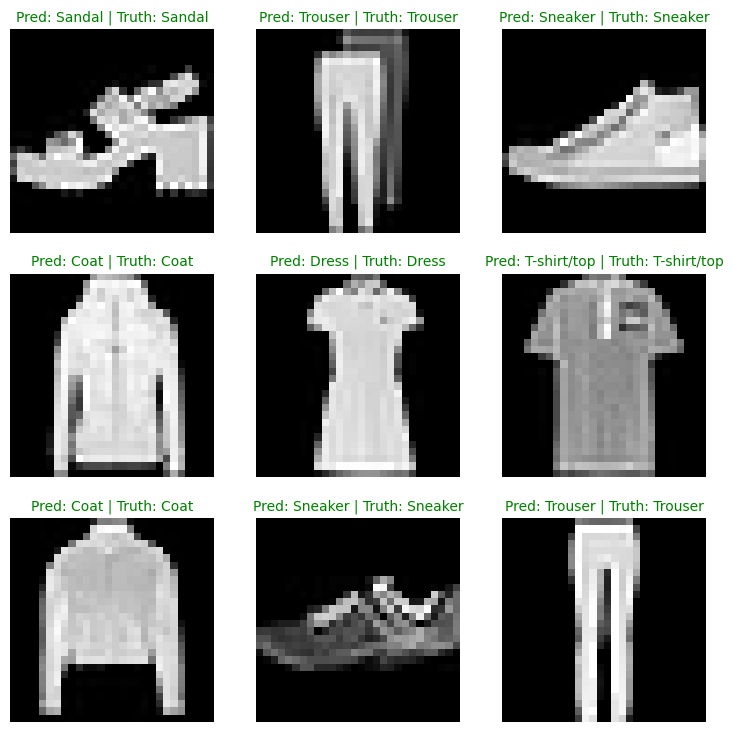

In [49]:
# Plot predictions
plt.figure(figsize=[9,9])
nrows = 3
ncols =3
for i,sample in enumerate(test_samples):
  # Create subplot
  plt.subplot(nrows,ncols,i+1)

  # Plot the target image
  plt.imshow(sample.squeeze(),cmap='gray')

  # Find the prediction
  pred_label = class_name[pred_classes[i]]

  # Get the truth label
  truth_label = class_name[test_labels[i]]

  # Title
  title_text = (f"Pred: {pred_label} | Truth: {truth_label}")

  # Check for equality
  if pred_label == truth_label:
    plt.title(title_text,fontsize=10,c='g')
  else:
    plt.title(title_text,fontsize=10,c='r')

  plt.axis(False)


# 11. Making a confusion matrix for further prediction evaluation
1. Make predictions with our model
2. Make a confusion matrix `torchmetrics.ConfusionMatrix`
3. Plot the confusion matrix using `mlxtend.plotting.plot_confusion_matrix()`

In [50]:
# 1. Make predictions with trained model
y_preds = []
model_2.eval()
with torch.inference_mode():
  for X,y in tqdm(test_dataloader, desc="Making predictions..."):
    # Put on device
    X,y = X.to(device), y.to(device)

    # Forward
    y_logit= model_2(X)

    # Convert to pred
    y_pred = torch.softmax(y_logit.squeeze(),dim=1).argmax(dim=1)

    y_preds.append(y_pred)

y_pred_tensor = torch.cat(y_preds)
y_pred_tensor

Making predictions...:   0%|          | 0/313 [00:00<?, ?it/s]

tensor([9, 2, 1,  ..., 8, 1, 5], device='cuda:0')

In [51]:
len(y_pred_tensor)

10000

In [52]:
try:
  import torchmetrics,mlxtend
  print(f"mlxtend version: {mlxtend.__version__}")
  assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend version should be 0.19.0 or higher"
except:
  !pip install torchmetrics -U mlxtend
  import torchmetrics, mlxtend
  print(f"mlxtend version: {mlxtend.__version__}")

mlxtend version: 0.24.0


In [57]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# Setup confusion instance and compare predictions to targets
confmat = ConfusionMatrix(num_classes=len(class_name),task='multiclass').to(device)
confmat_tensor = confmat(preds=y_pred_tensor.to(device),
                         target=test_datasets_fMNIST.targets.to(device))

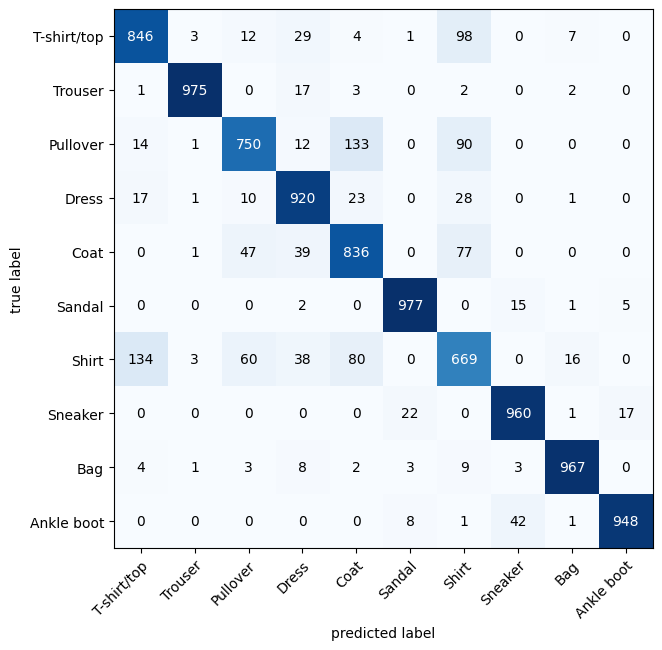

In [60]:
# Plot the confusion matrix
fig,ax = plot_confusion_matrix(conf_mat=confmat_tensor.cpu().numpy(),# matplotlib works with numpy
                               class_names = class_name,
                               figsize=[10,7])